# 0 - Supervisor vs solo: when does multi-agent earn its keep?

Same gold set, four topologies. Question: *does delegation actually help?*

| Topology | Coordination | Should win when |
|---|---|---|
| `solo` | flat agent, all tools | uniform tasks; tool-call overhead beats router |
| `supervisor` | central LLM router → specialist workers | heterogeneous tasks needing different skills |
| `hierarchical` | supervisor of supervisors (2 layers) | many domains, willing to pay double routing |
| `peer` | every worker in parallel, aggregator picks | unknown which specialist is right |

**Hypothesis.** Supervisor beats solo on heterogeneous tasks (routing pays back when workers have different jobs); on uniform tasks the delegation tax dominates. Hierarchical and peer add cost without proportional quality gains.

Results cache to `data/topology_results.csv`; re-running the analysis cells is instant.

In [1]:
import _path_setup  # noqa: F401

import json
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
assert os.environ.get("OPENROUTER_API_KEY"), "set OPENROUTER_API_KEY in .env"

from multi_agent import (
    build_solo, build_supervisor, build_hierarchical, build_peer,
    default_workers,
)
from shared import (
    load_chroma, load_bm25, load_gold_set,
    HybridRetriever, CrossEncoderReranker,
    judge_with_rubric,
)

DATA = Path("data")
DATA.mkdir(exist_ok=True)
RESULTS_CSV = DATA / "topology_results.csv"
TRACE_JSONL = DATA / "topology_traces.jsonl"

/Users/sinanozdemir/Teaching/Pearson/advanced-agentic-ai-in-three-weeks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Build the four topologies

Same workers (`researcher`, `summarizer`, `code_runner`), four wirings. The factories live in `src/multi_agent/topologies.py` so the SDR app in Segment 6 can import the same builders.

In [2]:
chroma = load_chroma()
bm25 = load_bm25()
hybrid = HybridRetriever(chroma, bm25, k=8)
reranker = CrossEncoderReranker()
workers = default_workers(hybrid, reranker, model_slug="openai/gpt-5.4-nano")

topologies = {
    "solo":         build_solo(workers, model_slug="openai/gpt-5.4-nano"),
    "supervisor":   build_supervisor(workers, supervisor_model="openai/gpt-5.4-nano"),
    "hierarchical": build_hierarchical(
        teams={
            "research_team": [workers[0]],                 # researcher only
            "analysis_team": [workers[1], workers[2]],     # summarizer + code_runner
        },
        top_model="openai/gpt-5.4-nano",
    ),
    "peer":         build_peer(workers, aggregator_model="openai/gpt-5.4-nano"),
}
print(f"Built {len(topologies)} topologies: {list(topologies)}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5883.66it/s]


Built 4 topologies: ['solo', 'supervisor', 'hierarchical', 'peer']


## The task set: deliberately heterogeneous

Three difficulty bands so the supervisor's value (or lack of it) shows up per band:

- **uniform** — pure retrieval. Topologies should tie (researcher only).
- **heterogeneous** — retrieval + summarization + arithmetic. Supervisor should pull ahead.
- **composite** — chains all three, output of one feeds the next.


In [3]:
TASKS = [
    # uniform: pure retrieval
    ("uniform_1",       "uniform",        "What does the AI Office Hours post say about positional bias in tool selection?"),
    ("uniform_2",       "uniform",        "How does Wikipedia describe BM25 as an information retrieval ranking function?"),
    # heterogeneous: retrieve + summarize + compute (different workers)
    ("heterogeneous_1", "heterogeneous",  "Summarize the AI Office Hours post on reranking RAG solutions in three bullets, then count the bullets."),
    ("heterogeneous_2", "heterogeneous",  "Find the cost per million input tokens of GPT-5.4-nano in the corpus, then compute total cost for 3.2M input tokens."),
    # composite: chain of all three
    ("composite_1",     "composite",      "Retrieve the key findings from the Voyager paper as discussed in the corpus, summarize them in 5 bullets, then report the bullet count."),
    ("composite_2",     "composite",      "From Wikipedia's RAG entry, extract the three named retrieval steps, summarize each in one sentence, then return their total character count."),
]

# Gold references for rubric correctness/completeness scoring.
# Keep these concise and specific to the task prompt.
REFERENCE_ANSWERS = {
    "uniform_1": (
        "The post argues tool-selection benchmarks are sensitive to positional bias: "
        "tools listed earlier are selected more often, so ordering can inflate or deflate measured accuracy."
    ),
    "uniform_2": (
        "Wikipedia describes BM25 as a probabilistic term-based ranking function in information retrieval "
        "that scores documents using term frequency saturation and length normalization, weighted by IDF."
    ),
    "heterogeneous_1": (
        "A good answer summarizes the reranking post's core point: use cheap first-pass retrieval "
        "(BM25 or dense) then a cross-encoder reranker for precision; final output should be three bullets and bullet count = 3."
    ),
    "heterogeneous_2": (
        "A good answer extracts GPT-5.4-nano input pricing from the corpus and computes 3.2M-token cost correctly "
        "as 3.2 × (price per 1M)."
    ),
    "composite_1": (
        "A good answer retrieves Voyager findings from the corpus, summarizes them in exactly 5 bullets, "
        "and reports bullet count = 5."
    ),
    "composite_2": (
        "A good answer names three retrieval-related steps from the RAG description, gives one-sentence summaries, "
        "then returns the total character count of those summaries."
    ),
}

print(f"{len(TASKS)} tasks across {len(set(t[1] for t in TASKS))} difficulty bands.")

6 tasks across 3 difficulty bands.


## Run the bake-off

4 topologies × 6 tasks × 3 runs = 72 trajectories. Each row is judged with the rubric from `judges.py`. CSV writes incrementally so you can interrupt and resume.

For a faster smoke test, set `N_RUNS = 1` and trim `TASKS`.

In [4]:
import time
from langchain_core.messages import HumanMessage

N_RUNS = 3
STRICT_FAITHFULNESS = False  # default for topology comparisons

# Resume support: skip rows already in the CSV.
if RESULTS_CSV.exists():
    done = pd.read_csv(RESULTS_CSV)
    done_keys = set(zip(done["topology"], done["query_id"], done["run_idx"]))
    print(f"Found {len(done)} cached rows. Resuming.")
else:
    done_keys = set()
    pd.DataFrame(columns=["topology", "model", "query_id", "difficulty", "question", "run_idx",
                          "answer", "overall", "correctness", "faithfulness", "completeness",
                          "conciseness", "input_tokens", "output_tokens", "cost_usd",
                          "latency_s", "n_worker_calls", "n_tool_calls"]).to_csv(RESULTS_CSV, index=False)

for topo_name, topo in topologies.items():
    for qid, diff, qtext in TASKS:
        for run_idx in range(N_RUNS):
            if (topo_name, qid, run_idx) in done_keys:
                continue
            t0 = time.time()
            try:
                result = topo.invoke({"task": qtext})
                err = None
            except Exception as exc:  # noqa: BLE001
                result = None
                err = repr(exc)
                print(f"  ERROR  [{topo_name} / {qid} / run{run_idx}]: {err}")
            elapsed = time.time() - t0

            if result is None:
                row = {"topology": topo_name, "model": "openai/gpt-5.4-nano",
                       "query_id": qid, "difficulty": diff, "question": qtext,
                       "run_idx": run_idx, "answer": err, "overall": 1.0,
                       "correctness": 1.0, "faithfulness": 1.0, "completeness": 1.0,
                       "conciseness": 1.0, "input_tokens": 0, "output_tokens": 0,
                       "cost_usd": 0.0, "latency_s": elapsed,
                       "n_worker_calls": 0, "n_tool_calls": 0}
            else:
                # Trajectory shapes differ per topology:
                #   supervisor / hierarchical -> dicts with 'result'
                #   peer                      -> dicts with 'answer'
                #   solo                      -> dicts with 'result' (added in topologies.py)
                evidence = [str(t.get("result") or t.get("answer") or "") for t in result.trajectory]
                evidence = [e for e in evidence if e] or None

                # STRICT_FAITHFULNESS=True is only valid when evidence is truly grounded
                # retrieval chunks. For topology experiments we default to False so
                # faithfulness falls back to the weaker reference-based check.
                evidence_for_judge = evidence if STRICT_FAITHFULNESS else None

                rubric = judge_with_rubric(
                    question=qtext,
                    answer=result.answer,
                    reference=REFERENCE_ANSWERS.get(qid, ""),
                    evidence=evidence_for_judge,
                )
                row = {"topology": topo_name, "model": "openai/gpt-5.4-nano",
                       "query_id": qid, "difficulty": diff, "question": qtext,
                       "run_idx": run_idx, "answer": result.answer,
                       "overall": rubric.overall, "correctness": rubric.correctness,
                       "faithfulness": rubric.faithfulness,
                       "completeness": rubric.completeness, "conciseness": rubric.conciseness,
                       "input_tokens": result.input_tokens,
                       "output_tokens": result.output_tokens,
                       "cost_usd": result.cost_usd, "latency_s": elapsed,
                       "n_worker_calls": result.n_worker_calls,
                       "n_tool_calls": result.n_tool_calls}
                print(f"  {topo_name:<13s} {qid:<18s} run{run_idx} -> overall={rubric.overall:.1f}  ${result.cost_usd:.4f}  {elapsed:.1f}s")

            pd.DataFrame([row]).to_csv(RESULTS_CSV, mode="a", header=False, index=False)

            trace_payload = {
                "topology": topo_name,
                "query_id": qid,
                "difficulty": diff,
                "run_idx": run_idx,
                "question": qtext,
                "strict_faithfulness": STRICT_FAITHFULNESS,
                "error": err,
                "row": row,
                "trajectory": (result.trajectory if result is not None else []),
            }
            with TRACE_JSONL.open("a", encoding="utf-8") as f:
                f.write(json.dumps(trace_payload) + "\n")

print("\nDone. Results in", RESULTS_CSV)
print("Trace dump in", TRACE_JSONL)
print("STRICT_FAITHFULNESS =", STRICT_FAITHFULNESS)

Found 72 cached rows. Resuming.

Done. Results in data/topology_results.csv
Trace dump in data/topology_traces.jsonl
STRICT_FAITHFULNESS = False


## Analysis

In [5]:
df = pd.read_csv(RESULTS_CSV)
print(f"{len(df)} rows: {df['topology'].nunique()} topologies × {df['query_id'].nunique()} questions × {df['run_idx'].nunique()} runs")
df.head()

72 rows: 4 topologies × 6 questions × 3 runs


,topology,model,query_id,difficulty,question,run_idx,answer,overall,correctness,faithfulness,completeness,conciseness,input_tokens,output_tokens,cost_usd,latency_s,n_worker_calls,n_tool_calls
0,solo,openai/gpt-5.4-nano,uniform_1,uniform,What does the AI Office Hours post say about p...,0,The AI Office Hours post says that **tool sele...,4.8,5,5,5,4,1142,188,0.000463,6.612925,0,1
1,solo,openai/gpt-5.4-nano,uniform_1,uniform,What does the AI Office Hours post say about p...,1,The AI Office Hours post says that **tool sele...,4.8,5,5,5,4,1142,206,0.000486,2.553577,0,1
2,solo,openai/gpt-5.4-nano,uniform_1,uniform,What does the AI Office Hours post say about p...,2,The AI Office Hours post says that **tool sele...,4.6,5,4,5,4,1142,162,0.000431,2.295331,0,1
3,solo,openai/gpt-5.4-nano,uniform_2,uniform,How does Wikipedia describe BM25 as an informa...,0,Wikipedia describes **BM25 (Okapi BM25)** as *...,3.8,4,5,3,3,1118,180,0.000449,4.755645,0,1
4,solo,openai/gpt-5.4-nano,uniform_2,uniform,How does Wikipedia describe BM25 as an informa...,1,Wikipedia describes **BM25 (Okapi BM25)** as:\...,3.8,4,5,3,3,1119,182,0.000451,3.043813,0,1


## Debugging traces for low-score runs

- `topology_results.csv` — rubric scores + final answer text.
- `topology_traces.jsonl` — per-run `trajectory` dumps (worker outputs / peer answers).

The next cell prints the worst runs.

In [6]:
import json

low = df[(df["topology"].isin(["solo", "peer"])) & (df["overall"] <= 2.0)].copy()
print(f"low rows: {len(low)}")
display(low[["topology", "difficulty", "query_id", "run_idx", "overall", "faithfulness", "correctness", "answer"]].head(12))

if TRACE_JSONL.exists():
    traces = []
    with TRACE_JSONL.open("r", encoding="utf-8") as f:
        for line in f:
            traces.append(json.loads(line))
    tdf = pd.DataFrame([{k: t[k] for k in ["topology", "difficulty", "query_id", "run_idx", "error"]} for t in traces])
    merged = low.merge(tdf, on=["topology", "difficulty", "query_id", "run_idx"], how="left")
    print("\nTrace rows found for low runs:", merged["error"].shape[0])

    # Print a few trajectories so you can inspect what workers actually said.
    print("\n=== sample trajectories (solo/peer low runs) ===")
    shown = 0
    for t in traces:
        if t["topology"] in {"solo", "peer"}:
            key = (t["topology"], t["query_id"], t["run_idx"])
            if ((low["topology"] == key[0]) & (low["query_id"] == key[1]) & (low["run_idx"] == key[2])).any():
                print(f"\n[{t['topology']} / {t['query_id']} / run{t['run_idx']}] error={t['error']}")
                print("trajectory:", json.dumps(t["trajectory"][:2], indent=2)[:1200])
                shown += 1
                if shown >= 5:
                    break
else:
    print("TRACE_JSONL not found. Re-run the bake-off cell to generate traces.")

low rows: 3


,topology,difficulty,query_id,run_idx,overall,faithfulness,correctness,answer
12,solo,composite,composite_1,0,1.80,3,1,I can’t reliably retrieve the “Voyager” paper’...
14,solo,composite,composite_1,2,1.57,5,1,I can’t reliably answer this as-is because the...
68,peer,composite,composite_1,2,1.40,3,1,I can’t retrieve or summarize the “Voyager” pa...



Trace rows found for low runs: 3

=== sample trajectories (solo/peer low runs) ===

[solo / composite_1 / run0] error=None
trajectory: [
  {
    "role": "solo",
    "messages": 6,
    "result": "I can\u2019t reliably retrieve the \u201cVoyager\u201d paper\u2019s key findings from the corpus based on what\u2019s currently available to me: the retrieval results returned unrelated documents (e.g., ImageNet, AlphaFold, a post about probing LLM world models) and did not surface the Voyager paper or its results.\n\nIf you can share the exact Voyager paper (title/authors/year or a link/PDF text), I can then pull its key findings from the corpus and produce the 5-bullet summary plus the bullet count.  \n\n**Bullet count:** 0"
  }
]

[solo / composite_1 / run2] error=None
trajectory: [
  {
    "role": "solo",
    "messages": 4,
    "result": "I can\u2019t reliably answer this as-is because the corpus results I can access right now don\u2019t include a \u201cVoyager\u201d paper (the retrieval o

## Quality by difficulty band

Supervisor should be tallest in `heterogeneous` and `composite`, ~tied with solo on `uniform`.

topology       solo  supervisor  hierarchical  peer
difficulty                                         
composite      2.58        3.24          3.18  2.47
heterogeneous  3.63        3.90          3.90  3.68
uniform        4.30        4.09          3.66  4.12


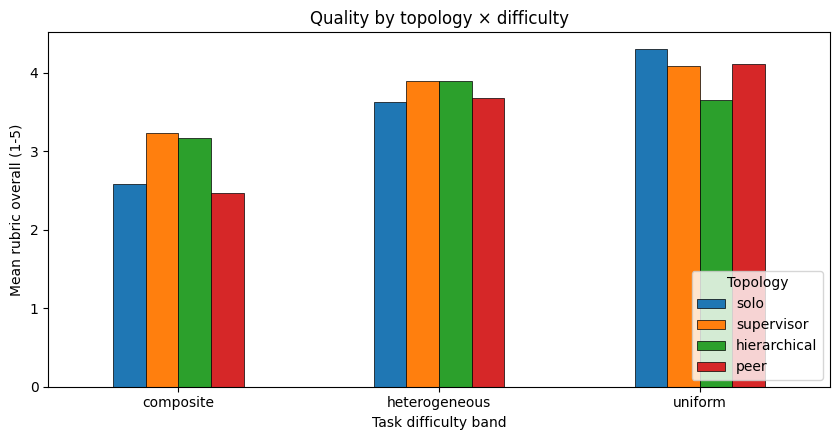

In [7]:
by_diff = df.groupby(["difficulty", "topology"])["overall"].mean().unstack()
ordered = [c for c in ["solo", "supervisor", "hierarchical", "peer"] if c in by_diff.columns]
by_diff = by_diff[ordered]
print(by_diff.round(2))

fig, ax = plt.subplots(figsize=(8.5, 4.5))
by_diff.plot(kind="bar", ax=ax, edgecolor="black", linewidth=0.5)
ax.set_ylabel("Mean rubric overall (1-5)")
ax.set_xlabel("Task difficulty band")
ax.set_title("Quality by topology × difficulty")
ax.legend(title="Topology", loc="lower right")
ax.set_xticklabels(by_diff.index, rotation=0)
plt.tight_layout()
plt.show()

## Cost: what does each topology charge for that quality?

In [8]:
summary = df.groupby("topology").agg(
    overall=("overall", "mean"),
    cost=("cost_usd", "mean"),
    latency=("latency_s", "mean"),
    workers=("n_worker_calls", "mean"),
).round(4)
ordered = [c for c in ["solo", "supervisor", "hierarchical", "peer"] if c in summary.index]
summary = summary.loc[ordered]
summary["$/quality_pt"] = (summary["cost"] / summary["overall"]).round(5)
summary

,overall,cost,latency,workers,$/quality_pt
topology,,,,,
solo,3.5039,0.0008,4.1694,0.0000,0.00023
supervisor,3.7422,0.0045,27.1955,3.8333,0.00120
hierarchical,3.5767,0.0095,55.0580,11.4444,0.00266
peer,3.4194,0.0010,7.8954,3.0000,0.00029


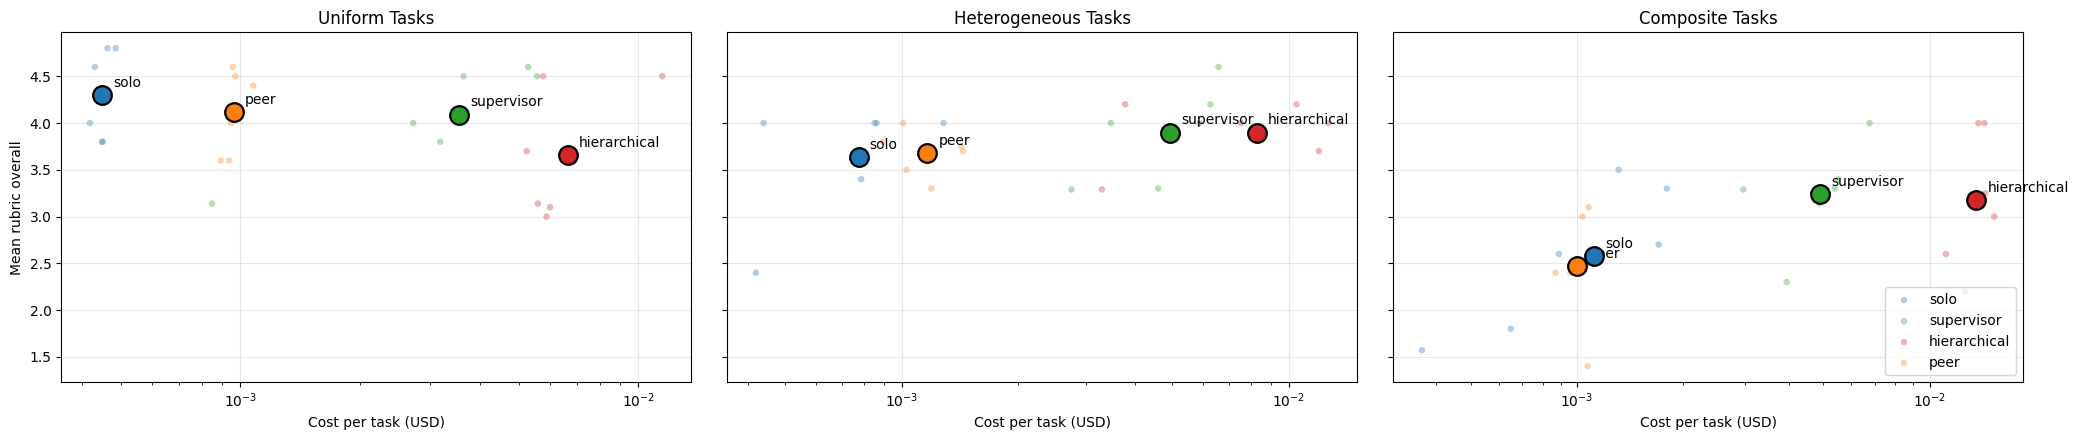

In [9]:
colors = {"solo": "#1f77b4", "supervisor": "#2ca02c",
          "hierarchical": "#d62728", "peer": "#ff7f0e"}
task_types = df["difficulty"].unique()
task_types = [t for t in ["uniform", "heterogeneous", "composite"] if t in task_types]  # sort if desired

fig, axes = plt.subplots(1, len(task_types), figsize=(7 * len(task_types), 4.5), sharey=True)
if len(task_types) == 1:
    axes = [axes]

for i, ttype in enumerate(task_types):
    ax = axes[i]
    for topo in summary.index:
        sub = df[(df["topology"] == topo) & (df["difficulty"] == ttype)]
        ax.scatter(sub["cost_usd"], sub["overall"], alpha=0.35, s=22,
                   c=colors.get(topo, "#888"), label=topo, edgecolor="none")
        if len(sub) > 0:
            cx, cy = sub["cost_usd"].mean(), sub["overall"].mean()
            ax.scatter([cx], [cy], s=180, c=colors.get(topo, "#888"),
                       edgecolor="black", linewidth=1.6, zorder=5)
            ax.annotate(topo, (cx, cy), xytext=(8, 6), textcoords="offset points", fontsize=10)
    ax.set_xlabel("Cost per task (USD)")
    if i == 0:
        ax.set_ylabel("Mean rubric overall")
    ax.set_title(f"{ttype.capitalize()} Tasks")
    ax.set_xscale("log")
    ax.grid(alpha=0.3)
    if i == len(task_types) - 1:
        ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## When to pick which topology

Updated against this run's data (not just the original hypothesis):

```
Are your tasks uniform (same skill per step)?
├── Yes → solo. Cheapest AND highest quality. Routing tax buys nothing.
│
└── No
    ├── Heterogeneous (multiple skills per task, no chaining)
    │   → supervisor. Beats solo by a small margin (~0.2 rubric pts) at
    │     ~5x the cost. Worth it when correctness matters; if you're
    │     cost-sensitive and solo is "good enough", stay solo.
    │
    └── Composite (output of one step feeds the next)
        → supervisor is the cost-quality sweet spot.
          hierarchical edges supervisor by ~0.2 pts but at 2-3x the cost,
          so only reach for it when (a) quality is paramount and
          (b) your domains naturally group into sub-teams.
```

**What changed from the original tree:**
- `peer` was deprioritized in the recommendation tree (still benchmarked above for completeness). In every difficulty band it was dominated — never cheapest, never highest-quality. The "hedge across specialists" intuition didn't pay off here.
- `hierarchical` is no longer the default for "many domains." On uniform and heterogeneous tasks it's strictly worse than supervisor; it only earns its keep on composite chains, and even then the margin is thin.

**Two cross-cutting findings:**
1. **Quality decays with composition regardless of topology.** Best topology drops ~4.3 → ~4.0 → ~3.2 as tasks chain. Orchestration doesn't fix a compositional task; that's prompting/decomposition.
2. **The only orchestration step that clearly earns its cost is solo → supervisor**, and only on multi-skill tasks. Anything beyond justifies itself with measurement.